In [1]:
"""2D Poisson-NEGF solver — square-lattice ribbon p-n junction (dolfinx FE)."""

import time
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

from mpi4py import MPI
import ufl
import basix.ufl
from dolfinx import fem, mesh as dmesh
from dolfinx.fem.petsc import LinearProblem
from petsc4py import PETSc
from scipy.spatial import Delaunay
import scipy.constants as spc

# Physical constants (SI)
E_CHARGE = 1.602176634e-19
EPS_0    = 8.854187817e-12
HBAR     = 1.054571817e-34
KB = spc.Boltzmann
T_KELVIN = 300.0
KT       = KB * T_KELVIN / E_CHARGE
V0       = KT
N_WORKERS = 32


def alpha_from_lattice(a_lat_nm):
    a_m = a_lat_nm * 1e-9
    return E_CHARGE / (EPS_0 * KT * a_m)
 
 
def doping_per_site(N_cm3, a_lat_nm):
    a_cm = a_lat_nm * 1e-7
    return N_cm3 * a_cm**3


# ====================================================================== #
#  GEOMETRY                                                              #
# ====================================================================== #
def make_geometry(W_rows, L_slices, a_lat=0.5):
    n_per = W_rows
    n_atoms = L_slices * n_per
    pos = np.zeros((n_atoms, 2))
    slice_idx = np.zeros(n_atoms, dtype=int)
    for s in range(L_slices):
        i0 = s * n_per
        for r in range(n_per):
            pos[i0 + r] = (s * a_lat, r * a_lat)
        slice_idx[i0:i0 + n_per] = s
    return pos, slice_idx, n_per, a_lat


def make_doping(slice_idx, L_p, L_i, Nd_value, Na_value):
    n_atoms = len(slice_idx)
    Nd = np.zeros(n_atoms); Na = np.zeros(n_atoms)
    Na[slice_idx < L_p] = Na_value
    Nd[slice_idx >= L_p + L_i] = Nd_value
    return Nd, Na



In [2]:

# ====================================================================== #
#  HAMILTONIAN — swap this function to change the model                  #
# ====================================================================== #
def build_slice_square(W, t_hop=1.0):
    H = np.zeros((W, W))
    V = np.zeros((W, W))
    for r in range(W - 1):
        H[r, r+1] = -t_hop; H[r+1, r] = -t_hop
    for r in range(W):
        V[r, r] = -t_hop
    return H, V


def build_device_H(H_slice, V_slice, L_slices):
    n_per = H_slice.shape[0]
    N = L_slices * n_per
    H = np.zeros((N, N), dtype=complex)
    for s in range(L_slices):
        i0 = s * n_per; i1 = i0 + n_per
        H[i0:i1, i0:i1] = H_slice
        if s + 1 < L_slices:
            j0 = i1; j1 = j0 + n_per
            H[i0:i1, j0:j1] = V_slice
            H[j0:j1, i0:i1] = V_slice.conj().T
    return H



In [3]:

# ====================================================================== #
#  LEAD SELF-ENERGY                                                      #
# ====================================================================== #
def sancho_rubio(z, H_slice, V_slice, max_iter=120, tol=1e-13):
    n = H_slice.shape[0]; I = np.eye(n, dtype=complex)
    H_eff = H_slice.astype(complex).copy()
    H_s = H_slice.astype(complex).copy()
    alpha = V_slice.astype(complex).copy()
    beta = V_slice.conj().T.astype(complex).copy()
    for _ in range(max_iter):
        g = np.linalg.solve(z*I - H_eff, I)
        ag = alpha @ g; bg = beta @ g
        H_s = H_s + ag @ beta
        H_eff = H_eff + ag @ beta + bg @ alpha
        alpha = ag @ alpha; beta = bg @ beta
        if max(np.max(np.abs(alpha)), np.max(np.abs(beta))) < tol:
            break
    return np.linalg.solve(z*I - H_s, I)


def sigma_LR(E, V_L, V_R, phi_p, phi_n, H_slice, V_slice, eta):
    n = H_slice.shape[0]
    H_lp = H_slice - phi_p * np.eye(n)
    H_ln = H_slice - phi_n * np.eye(n)
    g_L = sancho_rubio(E + V_L + 1j*eta, H_lp, V_slice)
    g_R = sancho_rubio(E + V_R + 1j*eta, H_ln, V_slice.conj().T)
    Sig_L = V_slice.conj().T @ g_L @ V_slice
    Sig_R = V_slice @ g_R @ V_slice.conj().T
    return Sig_L, Sig_R

def cache_self_energies(E_grid, V_L, V_R, phi_p, phi_n, H_slice, V_slice, eta,
                          verbose=True):
    n_E = len(E_grid)
    n_per = H_slice.shape[0]
    SL = np.zeros((n_E, n_per, n_per), dtype=complex)
    SR = np.zeros((n_E, n_per, n_per), dtype=complex)
    t0 = time.time()
    for k, E in enumerate(E_grid):
        SL[k], SR[k] = sigma_LR(E, V_L, V_R, phi_p, phi_n,
                                  H_slice, V_slice, eta)
    if verbose:
        print(f"  cached self-energies: {n_E} pts in {time.time()-t0:.1f}s")
    return SL, SR

    

In [4]:
from __future__ import annotations

import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure Eigen headers are discoverable for optional C++ extension build
for _cand in (
    "/usr/include/eigen3",
    "/usr/local/include/eigen3",
    str(Path.home() / ".local" / "eigen-src" / "eigen-3.4.0"),
):
    if os.path.isfile(f"{_cand}/Eigen/Core"):
        print('here')
        os.environ.setdefault("EIGEN_INCLUDE", _cand)
        break

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")


from negf.gf.recursive_greens_functions import _recursive_inverse as rgf

 
def density_at_E(E, H_eff, sigL, sigR, fL, fR, mu_eq, eta):
    GR_diag, _, _, _, _ = rgf(
        E, H_eff, sigL, sigR,
        compute_lesser=False, eta=eta,
        return_diag=True, return_gamma=True,
    )
    _, Glt_L, _, _, _ = rgf(
        E, H_eff, sigL, sigR,
        compute_lesser=True, occ_left=1.0, occ_right=0.0,
        eta=eta, return_diag=True, return_gamma=True,
    )
    _, Glt_R, _, _, _ = rgf(
        E, H_eff, sigL, sigR,
        compute_lesser=True, occ_left=0.0, occ_right=1.0,
        eta=eta, return_diag=True, return_gamma=True,
    )
 
    A   = -GR_diag.imag / np.pi
    A_L = +Glt_L.imag / (2*np.pi)
    A_R = +Glt_R.imag / (2*np.pi)
 
    f_eq = 1.0 / (1.0 + np.exp(np.clip((E - mu_eq)/KT, -200, 200)))
    dn = A_L * (fL - f_eq) + A_R * (fR - f_eq)
    n_E = A * f_eq + dn
    p_E = A * (1 - f_eq) - dn
    return A, n_E, p_E, GR_diag
 
 
_W = {}
 
 
def _init_worker(H_eff, eta, SL_cache, SR_cache):
    _W["H_eff"] = H_eff
    _W["eta"] = eta
    _W["SL"] = SL_cache
    _W["SR"] = SR_cache
 
 
def _compute_one(args):
    k, E, mu_L, mu_R, mu_eq = args
    sigL = _W["SL"][k]; sigR = _W["SR"][k]
    fL = 1.0 / (1.0 + np.exp(np.clip((E - mu_L)/KT, -200, 200)))
    fR = 1.0 / (1.0 + np.exp(np.clip((E - mu_R)/KT, -200, 200)))
    A, n_E, p_E, GR = density_at_E(E, _W["H_eff"], sigL, sigR,
                                     fL, fR, mu_eq, _W["eta"])
    f_eq = 1.0 / (1.0 + np.exp(np.clip((E - mu_eq)/KT, -200, 200)))
    J_E = -2 * (V0/np.pi) * np.imag(GR**2) * f_eq
    return n_E, p_E, A, J_E
 
 
def negf_density(phi_site, mu_L, mu_R, SL_cache, SR_cache,
                  H_dev, E_grid, eta,
                  n_workers=N_WORKERS, verbose=True):
    N = H_dev.shape[0]
    mu_eq = min(mu_L, mu_R)
    H_eff = H_dev - V0 * np.diag(phi_site).astype(complex)
    args = [(k, E_grid[k], mu_L, mu_R, mu_eq) for k in range(len(E_grid))]
    dE = np.gradient(E_grid)
    n_t = np.zeros(N); p_t = np.zeros(N); A_t = np.zeros(N); J_t = np.zeros(N)
    t0 = time.time()
    with ProcessPoolExecutor(max_workers=n_workers,
                              initializer=_init_worker,
                              initargs=(H_eff, eta, SL_cache, SR_cache)) as ex:
        for k, (n_E, p_E, A_E, J_E) in enumerate(ex.map(_compute_one, args)):
            n_t += n_E * dE[k]; p_t += p_E * dE[k]
            A_t += A_E * dE[k]; J_t += J_E * dE[k]
    if verbose:
        print(f"  NEGF: {len(E_grid)} E-pts in {time.time()-t0:.1f}s   "
              f"<A>={A_t.mean():.3f} <n>={n_t.mean():.3f} <p>={p_t.mean():.3f}")
    return n_t, p_t, J_t, A_t


here


In [ ]:
# ====================================================================== #
#  CURRENT (Landauer-Caroli, direct sparse inverse — no RGF)             #
# ====================================================================== #
import scipy.sparse as sp
import scipy.sparse.linalg as spla


def current_at_E(E, H_eff, sigL, sigR, V_slice, fL, fR, eta, slice_pair=None):
    """Landauer current kernel: I_E = T(E) * (fL - fR).

    T(E) = Tr[Gamma_L · G^R_{1,N} · Gamma_R · G^A_{N,1}]

    Direct: build (E+iη) I − H_eff − Σ_L − Σ_R, invert via sparse solve,
    extract the relevant blocks. No RGF.
    """
    N = H_eff.shape[0]
    nb = sigL.shape[0]

    Gamma_L = 1j * (sigL - sigL.conj().T)
    Gamma_R = 1j * (sigR - sigR.conj().T)

    # Build M = (E + i η) I − H_eff − Σ_L (top-left block) − Σ_R (bot-right block)
    M = (E + 1j*eta) * np.eye(N, dtype=complex) - H_eff
    M[:nb, :nb] -= sigL
    M[-nb:, -nb:] -= sigR

    # We only need two blocks of G^R = M^{-1}:
    #   G_1N (top-right nb × nb block)  for the trace
    # Solve M · X = B where B has identity in the LAST nb columns
    # then X[:nb, :] = G_1N
    B = np.zeros((N, nb), dtype=complex)
    B[-nb:, :] = np.eye(nb, dtype=complex)
    X = np.linalg.solve(M, B)
    G_1N = X[:nb, :]

    T_E = np.real(np.trace(Gamma_L @ G_1N @ Gamma_R @ G_1N.conj().T))
    return T_E * (fL - fR)
 
def _compute_current_one(args):
    k, E, V_L, V_R, mu_L, mu_R = args
    sigL = _W["SL"][k]; sigR = _W["SR"][k]
    fL = 1.0 / (1.0 + np.exp(np.clip((E - mu_L)/KT, -200, 200)))
    fR = 1.0 / (1.0 + np.exp(np.clip((E - mu_R)/KT, -200, 200)))
    return current_at_E(E, _W["H_eff"], sigL, sigR, _W["V_slice"],
                          fL, fR, _W["eta"])
 
 
def _init_worker_with_V(H_eff, eta, SL_cache, SR_cache, V_slice):
    _W["H_eff"] = H_eff
    _W["eta"] = eta
    _W["SL"] = SL_cache
    _W["SR"] = SR_cache
    _W["V_slice"] = V_slice
 
def compute_current(phi_site, mu_L, mu_R,
                      SL_cache, SR_cache, H_dev, V_slice, E_grid, eta,
                      n_workers=N_WORKERS, verbose=True):
    """Total current through the device (spinless; multiply by 2 for spin).

    Formula:  I = (e²/ πℏ) · ∫ dE · Im Tr[V_slice^† · Glt_offdiag[s](E)]
    """
    H_eff = H_dev - V0 * np.diag(phi_site).astype(complex)
    args = [(k, E_grid[k], 0.0, 0.0, mu_L, mu_R) for k in range(len(E_grid))]
    dE = np.gradient(E_grid)
    I_E = np.zeros(len(E_grid))

    t0 = time.time()
    with ProcessPoolExecutor(max_workers=n_workers,
                              initializer=_init_worker_with_V,
                              initargs=(H_eff, eta, SL_cache, SR_cache, V_slice)) as ex:
        for k, val in enumerate(ex.map(_compute_current_one, args)):
            I_E[k] = val

    I_internal = float(np.sum(I_E * dE))
    PREFACTOR = E_CHARGE**2 / (np.pi * HBAR)
    I_amps = PREFACTOR * I_internal

    if verbose:
        print(f"  current eval in {time.time()-t0:.1f}s   "
              f"I = {I_amps:.4e} A")
    return I_amps, I_E

In [6]:

# ====================================================================== #
#  MESH + DOF MAPS                                                       #
# ====================================================================== #
def build_mesh_from_pos(pos):
    tri = Delaunay(pos)
    cells = tri.simplices.astype(np.int64)
    element = basix.ufl.element("Lagrange", "triangle", 1, shape=(2,))
    domain = ufl.Mesh(element)
    return dmesh.create_mesh(MPI.COMM_WORLD, cells, domain, pos)


def build_dof_maps(V_space, pos):
    dof_coords = V_space.tabulate_dof_coordinates()[:, :2]
    n_atoms = len(pos)
    n_dofs = len(dof_coords)
    site_to_dof = np.zeros(n_atoms, dtype=int)
    dof_to_site = np.zeros(n_dofs, dtype=int)
    for i, p in enumerate(pos):
        d = np.argmin(np.sum((dof_coords - p)**2, axis=1))
        site_to_dof[i] = d
        dof_to_site[d] = i
    return site_to_dof, dof_to_site



In [7]:

# ====================================================================== #
#  POISSON FE                                                            #
# ====================================================================== #
class PoissonFE:
    def __init__(self, msh, V_space, site_to_dof, dof_to_site, pos, eps_x):
        self.msh = msh
        self.V = V_space
        self.s2d = site_to_dof
        self.d2s = dof_to_site

        self.phi          = fem.Function(V_space)
        self.phi_cand     = fem.Function(V_space)
        self.n_fn         = fem.Function(V_space)
        self.p_fn         = fem.Function(V_space)
        self.J_fn         = fem.Function(V_space)
        self.NdNa_fn      = fem.Function(V_space)

        x_min = pos[:, 0].min(); x_max = pos[:, 0].max()
        def left_edge(x):  return x[0] < x_min + eps_x
        def right_edge(x): return x[0] > x_max - eps_x
        self.left_dofs  = fem.locate_dofs_geometrical(V_space, left_edge)
        self.right_dofs = fem.locate_dofs_geometrical(V_space, right_edge)

    def make_problem(self, alpha, eps_r, BC_L, BC_R, prefix="poisson_"):
        u, v = ufl.TrialFunction(self.V), ufl.TestFunction(self.V)
        a = (eps_r * ufl.inner(ufl.grad(u), ufl.grad(v))
             + alpha * self.J_fn * u * v) * ufl.dx
        L = (alpha * (self.NdNa_fn - self.n_fn + self.p_fn
                      + self.J_fn * self.phi) * v) * ufl.dx
        bc_L = fem.dirichletbc(PETSc.ScalarType(BC_L), self.left_dofs, self.V)
        bc_R = fem.dirichletbc(PETSc.ScalarType(BC_R), self.right_dofs, self.V)
        self.bcs = [bc_L, bc_R]
        self.problem = LinearProblem(
            a, L, u=self.phi_cand, bcs=self.bcs,
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix=prefix,
        )

    def set_inputs(self, n_site, p_site, J_site, NdNa_site):
        self.n_fn.x.array[:]    = n_site[self.d2s]
        self.p_fn.x.array[:]    = p_site[self.d2s]
        self.J_fn.x.array[:]    = J_site[self.d2s]
        self.NdNa_fn.x.array[:] = NdNa_site[self.d2s]

    def solve_step(self):
        self.problem.solve()
        return self.phi_cand.x.array.copy()

    def get_phi_site(self):
        return self.phi.x.array[self.s2d]

    def set_phi_site(self, phi_site):
        self.phi.x.array[:] = phi_site[self.d2s]
        fem.set_bc(self.phi.x.array, self.bcs)


# ====================================================================== #
#  ITERATION HELPERS                                                     #
# ====================================================================== #
def gummel_J(n_site, p_site):
    return (V0 / KT) * (n_site + p_site)


def anderson_step(phi_in, residual_F, history, mix):
    if len(history) >= 2:
        phi_hist = np.array([h[0] for h in history])
        res_hist = np.array([h[1] for h in history])
        dF = res_hist[1:] - res_hist[:-1]
        dphi = phi_hist[1:] - phi_hist[:-1]
        try:
            gamma, *_ = np.linalg.lstsq(dF.T, residual_F, rcond=None)
            return phi_in + mix * residual_F - (dphi.T + dF.T) @ gamma * mix
        except np.linalg.LinAlgError:
            pass
    return phi_in + mix * residual_F


def update_history(history, phi_in, residual_F, depth):
    history.append((phi_in.copy(), residual_F.copy()))
    if len(history) > depth:
        history.pop(0)


# ====================================================================== #
#  PER-SLICE HELPERS                                                     #
# ====================================================================== #
def to_slice(arr, slice_idx, L):
    return np.array([arr[slice_idx == s].mean() for s in range(L)])


def from_slice(arr_s, slice_idx):
    return arr_s[slice_idx]



In [8]:

# ====================================================================== #
#  AUTO-TUNE: find phi_BC values that give bulk charge neutrality        #
# ====================================================================== #
def find_neutral_phi(
    W_rows, L_slices, L_p, L_i,
    Nd_value, Na_value,
    t_hop, a_lat,
    mu_ref=0.0, eta_negf=0.030,
    phi_range=(-0.5, 0.5), n_points=11,
    E_grid=None,
    n_workers=N_WORKERS, verbose=True,
):
    pos, slice_idx, n_per, _ = make_geometry(W_rows, L_slices, a_lat)
    Nd, Na = make_doping(slice_idx, L_p, L_i, Nd_value, Na_value)
    H_slice, V_slice = build_slice_square(W_rows, t_hop=t_hop)
    H_dev = build_device_H(H_slice, V_slice, L_slices)
    n_atoms = H_dev.shape[0]
 
    if E_grid is None:
        E_grid = np.linspace(-4.5*t_hop, 4.5*t_hop, 121)
 
    L_n = L_slices - L_p - L_i
    p_lo, p_hi = 3, max(L_p - 5, 4)
    n_lo, n_hi = L_p + L_i + 5, max(L_slices - 3, L_p + L_i + 6)
 
    phis = np.linspace(phi_range[0], phi_range[1], n_points)
    rho_p_arr = np.zeros(n_points)
    rho_n_arr = np.zeros(n_points)
 
    if verbose:
        print(f"  auto-tune phi sweep ({n_points} pts)...")
 
    for k, phi_test in enumerate(phis):
        phi_atom = np.full(n_atoms, phi_test / V0)
        SL, SR = cache_self_energies(E_grid, 0.0, 0.0, phi_test, phi_test,
                                       H_slice, V_slice, eta_negf, verbose=False)
        n, p, _, _ = negf_density(
            phi_atom, mu_ref, mu_ref, SL, SR,
            H_dev, E_grid, eta=eta_negf,
            n_workers=n_workers, verbose=False)
        rho = (Nd - Na) - n + p
        rho_s = to_slice(rho, slice_idx, L_slices)
        rho_p_arr[k] = rho_s[p_lo:p_hi].mean()
        rho_n_arr[k] = rho_s[n_lo:n_hi].mean()
        if verbose:
            print(f"    phi={phi_test:+.3f}  rho_p={rho_p_arr[k]:+.4f}  "
                  f"rho_n={rho_n_arr[k]:+.4f}")
 
    def find_zero(x, y):
        for i in range(len(y) - 1):
            if y[i] * y[i+1] < 0:
                return x[i] + (x[i+1] - x[i]) * y[i] / (y[i] - y[i+1])
        return None
 
    phi_p_BC = find_zero(phis, rho_p_arr)
    phi_n_BC = find_zero(phis, rho_n_arr)
 
    if verbose:
        print(f"  -> phi_p_BC = {phi_p_BC}, phi_n_BC = {phi_n_BC}")
 
    return phi_p_BC, phi_n_BC
 
 
# ====================================================================== #
#  MAIN SOLVER                                                           #
# ====================================================================== #
def self_consistent_solve(
    W_rows=5, L_slices=60, L_p=30, L_i=0,
    Nd_value=0.05, Na_value=0.05,
    t_hop=1.0, a_lat=0.5,
    V_DS=0.0, mu_ref=0.0,
    phi_p_BC=None, phi_n_BC=None,
    alpha=None, eps_r=11.7,
    eta_negf=0.030,
    E_grid=None,
    mix=0.5, max_iter=40, tol=1e-3,
    anderson_depth=5,
    n_workers=N_WORKERS,
    verbose=True,
):
    if alpha is None:
        alpha = alpha_from_lattice(a_lat)
        if verbose:
            print(f"  alpha (from a_lat={a_lat}) = {alpha:.2f}")
 
    if phi_p_BC is None or phi_n_BC is None:
        phi_p_auto, phi_n_auto = find_neutral_phi(
            W_rows, L_slices, L_p, L_i, Nd_value, Na_value,
            t_hop, a_lat, mu_ref=mu_ref, eta_negf=eta_negf,
            E_grid=E_grid, n_workers=n_workers, verbose=verbose)
        if phi_p_BC is None: phi_p_BC = phi_p_auto
        if phi_n_BC is None: phi_n_BC = phi_n_auto
        if phi_p_BC is None or phi_n_BC is None:
            raise RuntimeError(
                "Auto-tune failed to find charge-neutral phi (no zero crossing). "
                "Try a wider phi_range, larger doping, or set phi_p_BC/phi_n_BC manually."
            )
 
    pos, slice_idx, n_per, a_lat = make_geometry(W_rows, L_slices, a_lat)
    Nd, Na = make_doping(slice_idx, L_p, L_i, Nd_value, Na_value)
    H_slice, V_slice = build_slice_square(W_rows, t_hop=t_hop)
    H_dev = build_device_H(H_slice, V_slice, L_slices)
 
    msh = build_mesh_from_pos(pos)
    V_space = fem.functionspace(msh, ("Lagrange", 1))
    s2d, d2s = build_dof_maps(V_space, pos)
 
    poisson = PoissonFE(msh, V_space, s2d, d2s, pos, eps_x=0.5*a_lat)
    BC_L = phi_p_BC / V0
    BC_R = (phi_n_BC + V_DS) / V0
    poisson.make_problem(alpha, eps_r, BC_L, BC_R)
 
    phi_init_s = np.linspace(BC_L, BC_R, L_slices)
    poisson.set_phi_site(from_slice(phi_init_s, slice_idx))
 
    if E_grid is None:
        E_grid = np.linspace(-4.5, 4.5, 121)
 
    V_L_app, V_R_app = 0.0, V_DS
    mu_L = mu_ref - V_L_app
    mu_R = mu_ref - V_R_app
    NdNa = Nd - Na
 
    SL_cache, SR_cache = cache_self_energies(
        E_grid, V_L_app, V_R_app, phi_p_BC, phi_n_BC,
        H_slice, V_slice, eta_negf, verbose=verbose)
 
    history = {"residual": [], "rho_p": [], "rho_n": []}
    anderson_history = []
 
    L_n = L_slices - L_p - L_i
 
    for it in range(max_iter):
        t0 = time.time()
        phi_site = poisson.get_phi_site()
 
        n, p, J_AH, A = negf_density(
            phi_site, mu_L, mu_R, SL_cache, SR_cache,
            H_dev, E_grid, eta=eta_negf,
            n_workers=n_workers, verbose=verbose)
 
        rho = NdNa - n + p
        rho_s = to_slice(rho, slice_idx, L_slices)
        p_lo, p_hi = 3, max(L_p - 5, 4)
        n_lo, n_hi = L_p + L_i + 5, max(L_slices - 3, L_p + L_i + 6)
        rho_p_bulk = rho_s[p_lo:p_hi].mean()
        rho_n_bulk = rho_s[n_lo:n_hi].mean()
 
        J_use = gummel_J(n, p)
 
        poisson.set_inputs(n, p, J_use, NdNa)
        phi_newton_dof = poisson.solve_step()
 
        phi_dof_in = poisson.phi.x.array.copy()
        residual_F = phi_newton_dof - phi_dof_in
        phi_dof_new = anderson_step(phi_dof_in, residual_F,
                                      anderson_history, mix)
        update_history(anderson_history, phi_dof_in, residual_F, anderson_depth)
 
        delta = np.clip(phi_dof_new - phi_dof_in, -10, 10)
        poisson.phi.x.array[:] = phi_dof_in + delta
        fem.set_bc(poisson.phi.x.array, poisson.bcs)
 
        res = float(np.max(np.abs(delta)))
        history["residual"].append(res)
        history["rho_p"].append(rho_p_bulk)
        history["rho_n"].append(rho_n_bulk)
 
        if verbose:
            print(f"  iter {it+1:2d}  |dphi|={res:.3e}  "
                  f"rho_p={rho_p_bulk:+.4f}  rho_n={rho_n_bulk:+.4f}  "
                  f"({time.time()-t0:.1f}s)")
        if res < tol:
            if verbose: print(f"  converged at iter {it+1}")
            break
 
    phi_site_final = poisson.get_phi_site()
    n_final, p_final, _, _ = negf_density(
        phi_site_final, mu_L, mu_R, SL_cache, SR_cache,
        H_dev, E_grid, eta=eta_negf,
        n_workers=n_workers, verbose=verbose)
    rho_final = NdNa - n_final + p_final
 
    return {
        "pos": pos, "slice_idx": slice_idx, "L_slices": L_slices, "a_lat": a_lat,
        "phi_site": phi_site_final, "phi_dof": poisson.phi.x.array.copy(),
        "n": n_final, "p": p_final, "rho": rho_final,
        "Nd": Nd, "Na": Na, "history": history,
        "phi_p_BC": phi_p_BC, "phi_n_BC": phi_n_BC,
        "alpha": alpha,
    }
 
 
# ====================================================================== #
#  PLOTTING                                                              #
# ====================================================================== #
def plot_result(res, V_DS, tol, save_path=None):
    L = res["L_slices"]; sl = res["slice_idx"]; a = res["a_lat"]
    x = np.arange(L) * a
    def per_slice(arr): return to_slice(arr, sl, L)
 
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
 
    ax = axes[0, 0]
    ax.semilogy(np.arange(1, len(res["history"]["residual"])+1),
                res["history"]["residual"], "o-")
    ax.axhline(tol, color="red", ls=":")
    ax.set_xlabel("iter"); ax.set_ylabel("|dphi|_max V0")
    ax.set_title("Convergence"); ax.grid(alpha=0.3, which="both")
 
    ax = axes[0, 1]
    ax.plot(x, per_slice(res["phi_site"]) * V0, "o-", ms=4)
    ax.set_xlabel("x (nm)"); ax.set_ylabel("phi (V)")
    ax.set_title(f"phi(x), V_DS={V_DS}")
    ax.grid(alpha=0.3)
 
    ax = axes[1, 0]
    ax.plot(x, per_slice(res["n"]), "C0o-", label="n", ms=4)
    ax.plot(x, per_slice(res["p"]), "C3o-", label="p", ms=4)
    ax.plot(x, per_slice(res["Nd"]), "C0--", alpha=0.5, label="Nd")
    ax.plot(x, per_slice(res["Na"]), "C3--", alpha=0.5, label="Na")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("density per site")
    ax.set_title("Carriers"); ax.legend(); ax.grid(alpha=0.3)
 
    ax = axes[1, 1]
    ax.plot(x, per_slice(res["rho"]), "k-", lw=2)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("x (nm)"); ax.set_ylabel("rho")
    ax.set_title("Net charge per slice"); ax.grid(alpha=0.3)
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130)
    return fig
  
# if __name__ == "__main__":
#     a_lat   = 0.5             # nm — coarse-grained site spacing
#     t_hop   = 1.0             # eV (back to the unit-of-bandwidth choice)
#     eps_r   = 11.7

#     W_rows   = 20
#     L_slices = 200
#     L_p, L_i = 60, 80

#     Nd_cm3 = 1e20
#     Na_cm3 = 1e20

#     Nd_value = doping_per_site(Nd_cm3, a_lat)
#     Na_value = doping_per_site(Na_cm3, a_lat)

#     print(f"Nd={Nd_value:.4f}, Na={Na_value:.4f}, alpha={alpha_from_lattice(a_lat):.1f}")
#     # Should give: Nd=Na ≈ 0.0125, alpha ≈ 1400
 

#     res_eq = self_consistent_solve(
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat,
#         V_DS=0.0, mu_ref=0.0,
#         eps_r=eps_r,
#         mix=0.5, max_iter=40, tol=1e-3,
#     )
#     plot_result(res_eq, V_DS=0.0, tol=1e-3,
#                  save_path="poisson_negf_2d_dolfinx_eq.png")
 
#     res_bias = self_consistent_solve(
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat,
#         V_DS=0.10, mu_ref=0.0,
#         phi_p_BC=res_eq.get("phi_p_BC"), phi_n_BC=res_eq.get("phi_n_BC"),
#         eps_r=eps_r,
#         mix=0.5, max_iter=40, tol=1e-3,
#     )
#     plot_result(res_bias, V_DS=0.10, tol=1e-3,
#                  save_path="poisson_negf_2d_dolfinx_bias.png")


In [9]:
# """IV curve sweep — Path B: operate in band tail for semiconductor-like behavior.

# Key change from default: mu_ref = -3.5 (instead of 0).
# - At mu_ref = 0 (band center), DOS is huge → metallic transport, linear IV.
# - At mu_ref = -3.5 (near band edge), DOS is small → semiconductor-like, can see
#   rectification. Effective parabolic dispersion, single Fermi surface, low carrier density.

# The auto-tune phi_range needs adjustment because charge-neutral phi values shift
# with mu_ref. We'll sweep over a wider, asymmetric range to capture this.
# """
# import numpy as np
# import matplotlib.pyplot as plt



# def iv_sweep_path_b(
#     V_DS_list,
#     W_rows, L_slices, L_p, L_i,
#     Nd_value, Na_value,
#     t_hop, a_lat, eps_r,
#     mu_ref=-3.5,                     # KEY: operating point near band bottom
#     eta_negf=0.030,
#     E_grid=None,
#     phi_range=(-1.0, 1.0),           # wider scan for auto-tune
#     n_phi_points=21,
#     mix=0.5, max_iter=40, tol=1e-3,
#     save_dir=".",
#     verbose=True,
# ):
#     """IV sweep operating at mu_ref < 0 (band tail)."""
#     if E_grid is None:
#         # Focus E grid around mu_ref since that's where the bias window lives
#         # but extend wide enough to catch all relevant transmission
#         E_grid = np.linspace(mu_ref - 1.5, mu_ref + 1.5, 121)

#     # Build static device pieces once
#     H_slice, V_slice = build_slice_square(W_rows, t_hop=t_hop)
#     H_dev = build_device_H(H_slice, V_slice, L_slices)

#     # Auto-tune at the new mu_ref. The phi values that give bulk neutrality
#     # are different from the mu_ref=0 case.
#     print(f"\n{'='*60}")
#     print(f"Auto-tuning lead BCs at mu_ref = {mu_ref}")
#     print(f"{'='*60}")
#     phi_p_BC, phi_n_BC = find_neutral_phi(
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat,
#         mu_ref=mu_ref, eta_negf=eta_negf,
#         phi_range=phi_range, n_points=n_phi_points,
#         E_grid=E_grid, verbose=verbose,
#     )
#     print(f"\n  phi_p_BC = {phi_p_BC:+.4f} V")
#     print(f"  phi_n_BC = {phi_n_BC:+.4f} V")
#     print(f"  built-in V_bi = phi_n_BC - phi_p_BC = {phi_n_BC - phi_p_BC:+.4f} V")

#     # Equilibrium solve to verify the auto-tuned BCs work
#     print(f"\n{'='*60}\nEquilibrium solve (V_DS = 0)\n{'='*60}")
#     res_eq = self_consistent_solve(
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat,
#         V_DS=0.0, mu_ref=mu_ref,
#         phi_p_BC=phi_p_BC, phi_n_BC=phi_n_BC,
#         eps_r=eps_r, eta_negf=eta_negf, E_grid=E_grid,
#         mix=mix, max_iter=max_iter, tol=tol,
#         verbose=verbose,
#     )

#     plot_result(res_eq, V_DS=0.0, tol=tol,
#                  save_path=f"{save_dir}/iv_pathB_eq.png")

#     # Bias sweep
#     I_list = np.zeros(len(V_DS_list))
#     results = []

#     for k, V_DS in enumerate(V_DS_list):
#         print(f"\n{'='*60}\nBias point {k+1}/{len(V_DS_list)}: "
#                f"V_DS = {V_DS:+.3f} V\n{'='*60}")

#         res = self_consistent_solve(
#             W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#             Nd_value=Nd_value, Na_value=Na_value,
#             t_hop=t_hop, a_lat=a_lat,
#             V_DS=V_DS, mu_ref=mu_ref,
#             phi_p_BC=phi_p_BC, phi_n_BC=phi_n_BC,
#             eps_r=eps_r, eta_negf=eta_negf, E_grid=E_grid,
#             mix=mix, max_iter=max_iter, tol=tol,
#             verbose=verbose,
#         )

#         SL_cache, SR_cache = cache_self_energies(
#             E_grid, 0.0, V_DS, phi_p_BC, phi_n_BC,
#             H_slice, V_slice, eta_negf, verbose=False)

#         I, I_E = compute_current(
#             res["phi_site"], mu_ref, mu_ref - V_DS,
#             SL_cache, SR_cache, H_dev, V_slice, E_grid, eta_negf,
#             verbose=False)

#         I_list[k] = I
#         results.append(res)
#         print(f"  I = {I:.4e} A")

#     return V_DS_list, I_list, results, res_eq, (phi_p_BC, phi_n_BC)


# def plot_iv_pathB(V_DS_arr, I_arr, V_bi=None, save_path=None):
#     fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

#     ax = axes[0]
#     ax.plot(V_DS_arr, I_arr * 1e9, "o-", ms=5)
#     ax.axhline(0, color="gray", lw=0.5)
#     ax.axvline(0, color="gray", lw=0.5)
#     if V_bi is not None:
#         ax.axvline(V_bi, color="red", lw=0.5, ls=":", label=f"V_bi = {V_bi:.3f} V")
#         ax.legend()
#     ax.set_xlabel(r"$V_{DS}$ (V)")
#     ax.set_ylabel(r"$I$ (nA)")
#     ax.set_title("Linear scale")
#     ax.grid(alpha=0.3)

#     ax = axes[1]
#     pos = I_arr > 0
#     neg = I_arr < 0
#     if pos.any():
#         ax.semilogy(V_DS_arr[pos], I_arr[pos], "C0o-", ms=5, label="forward")
#     if neg.any():
#         ax.semilogy(V_DS_arr[neg], -I_arr[neg], "C3s-", ms=5, label="|reverse|")
#     ax.set_xlabel(r"$V_{DS}$ (V)")
#     ax.set_ylabel(r"$|I|$ (A)")
#     ax.set_title("Log scale (|I|)")
#     ax.legend()
#     ax.grid(alpha=0.3, which="both")

#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=130)
#     return fig


# if __name__ == "__main__":
#     a_lat   = 0.5
#     t_hop   = 1.0
#     eps_r   = 11.7
#     W_rows   = 20
#     L_slices = 200
#     L_p, L_i = 60, 80

#     Nd_value = doping_per_site(1e20, a_lat)
#     Na_value = doping_per_site(1e20, a_lat)
#     print(f"Nd={Nd_value:.4f}, Na={Na_value:.4f}, "
#           f"alpha={alpha_from_lattice(a_lat):.1f}")

#     V_DS_arr = np.array([
#         -0.30, -0.20, -0.10, -0.05, -0.02,
#         0.00,
#         0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50,
#     ])

#     V_DS_arr, I_arr, results, res_eq, (phi_p, phi_n) = iv_sweep_path_b(
#         V_DS_list=V_DS_arr,
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat, eps_r=eps_r,
#         mu_ref=-3.5,
#         save_dir=".",
#     )

#     V_bi = phi_n - phi_p

#     print("\n" + "="*60)
#     print("IV curve summary (Path B):")
#     print(f"  mu_ref = -3.5  (band tail, semiconductor-like)")
#     print(f"  V_bi = {V_bi:.4f} V")
#     print(f"\n{'V_DS (V)':>12s}  {'I (A)':>14s}")
#     for V, I in zip(V_DS_arr, I_arr):
#         print(f"{V:>12.4f}  {I:>14.4e}")
#     print("="*60)

#     plot_iv_pathB(V_DS_arr, I_arr, V_bi=V_bi, save_path="iv_curve_pathB.png")
#     print("saved iv_curve_pathB.png")

#     np.savez("iv_data_pathB.npz",
#               V_DS=V_DS_arr, I=I_arr,
#               phi_p_BC=phi_p, phi_n_BC=phi_n, V_bi=V_bi)
#     print("saved iv_data_pathB.npz")

H_slice shape: (20, 20)
V_slice shape: (20, 20)
H Hermitian: True


/tmp/ipykernel_67853/2859149244.py:103: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


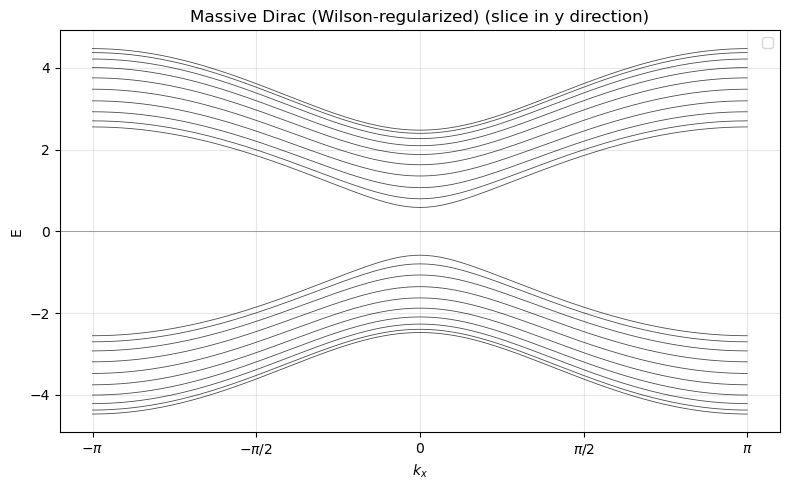

In [10]:
"""Massive Dirac on square lattice — 2-orbital, real bandgap, no doublers.

Continuum:  H = v(k_x σ_x + k_y σ_y) + m σ_z
Bands: E_± = ±√(v²(k_x²+k_y²) + m²)
Gap: 2|m| (at k=0)

Discretize on square lattice via central differences. To kill the doublers
that central difference would otherwise generate, add a Wilson term
-r(cos k_x - 1)σ_z that vanishes at k=0 and gaps the BZ-edge cones.
Combined Wilson + mass shifts the diagonal sigma_z coefficient.

In tight-binding form (per site, 2 orbitals A/B):
    H_on  = (m + 2r) σ_z
    H_x   = +i v/2 σ_x  - (r/2) σ_z   (NN hop in +x direction)
    H_y   = +i v/2 σ_y  - (r/2) σ_z   (NN hop in +y direction)

This is a drop-in for build_slice_square: same call signature, same return
types (H_slice, V_slice), same slice structure. Just 2× more orbitals.
"""
import numpy as np

I2 = np.eye(2, dtype=complex)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)


def build_slice_dirac(W, t_hop=1.0, m=0.5, r_wilson=None):
    """2-orbital massive Dirac slice with Wilson regularization.

    Args:
        W: number of sites (transverse direction, y)
        t_hop: hopping amplitude (this is "v" in the Dirac sense, also sets
                bandwidth scale) — keep the same arg name as build_slice_square
                for drop-in compatibility
        m: mass (gap = 2|m|)
        r_wilson: Wilson coefficient. Default = t_hop (standard choice that
                gaps the doubler at the same scale as the kinetic bandwidth)

    Returns:
        H_slice (2W × 2W): on-site + intra-slice (y-direction) hopping
        V_slice (2W × 2W): inter-slice (+x-direction) hopping
    """
    if r_wilson is None:
        r_wilson = t_hop

    n_orb = 2
    n = n_orb * W
    H = np.zeros((n, n), dtype=complex)
    V = np.zeros((n, n), dtype=complex)

    # On-site: m σ_z + Wilson contribution from BOTH x AND y (each contributes
    # +r σ_z on-site, hops contribute -r/2 σ_z per direction)
    on_site = (m + 2 * r_wilson) * sigma_z

    for r in range(W):
        H[2*r:2*r+2, 2*r:2*r+2] = on_site

    # Intra-slice (y-direction) NN hop: i v/2 σ_y - r/2 σ_z
    H_y_hop = +1j * t_hop / 2 * sigma_y - (r_wilson / 2) * sigma_z
    for r in range(W - 1):
        H[2*r:2*r+2, 2*(r+1):2*(r+1)+2] = H_y_hop
        H[2*(r+1):2*(r+1)+2, 2*r:2*r+2] = H_y_hop.conj().T

    # Inter-slice (+x-direction) NN hop: i v/2 σ_x - r/2 σ_z
    V_x_hop = +1j * t_hop / 2 * sigma_x - (r_wilson / 2) * sigma_z
    for r in range(W):
        V[2*r:2*r+2, 2*r:2*r+2] = V_x_hop

    return H, V


# ====================================================================== #
#  Sanity checks
# ====================================================================== #
def plot_bands(W=10, t_hop=1.0, m=0.5, save_path=None):
    """Plot E(k_x) for the lead unit cell. Should show a gap of 2*m."""
    import matplotlib.pyplot as plt

    H_slice, V_slice = build_slice_dirac(W, t_hop=t_hop, m=m)

    n_k = 201
    kx = np.linspace(-np.pi, np.pi, n_k)
    bands = np.zeros((n_k, 2*W))
    for ik, k in enumerate(kx):
        Hk = H_slice + V_slice * np.exp(1j*k) + V_slice.conj().T * np.exp(-1j*k)
        e = np.linalg.eigvalsh(Hk)
        bands[ik] = np.sort(e.real)

    fig, ax = plt.subplots(figsize=(8, 5))
    for b in range(2*W):
        ax.plot(kx, bands[:, b], 'k-', lw=0.6, alpha=0.7)
    ax.axhline(0, color='gray', lw=0.5)

    valence_top = bands[:, W-1].max()
    conduction_bottom = bands[:, W].min()
    gap = conduction_bottom - valence_top
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel('E')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_title(f'Massive Dirac (Wilson-regularized) (slice in y direction)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130)
    return fig


if __name__ == "__main__":
    H_slice, V_slice = build_slice_dirac(W=10, t_hop=1.0, m=0.5)
    print(f"H_slice shape: {H_slice.shape}")
    print(f"V_slice shape: {V_slice.shape}")
    print(f"H Hermitian: {np.allclose(H_slice, H_slice.conj().T)}")

    plot_bands(W=10, t_hop=1.0, m=0.5, save_path="dirac_bands.png")
    

In [11]:
"""Diode physics with massive Dirac lattice (real bandgap, no doublers).

Wraps the existing Poisson-NEGF pipeline but replaces the slice builder.
Handles the 2-orbitals-per-site bookkeeping:
  - Poisson sees per-site electrostatic potential phi_site (length n_atoms)
  - NEGF Hamiltonian has 2 orbitals per site, size 2*n_atoms
  - n, p returned by NEGF must be summed over orbital-pair to get per-site

The trick: when applying phi to H_dev, we broadcast phi_site → per-orbital
(both orbitals at site i feel the same phi[i]). And when reading n, p from
NEGF, we sum over the orbital pair.

KEY MODIFICATIONS:
  - density_at_E_dirac:      sums n_E, p_E over orbital pairs at each site
  - build_device_H_dirac:    uses build_slice_dirac internally
  - cache_self_energies_dirac: same as before, just uses 2W lead size
  - The 'phi_site' applied as -V0*phi*I ALREADY broadcasts correctly because
    Kron-extending diag(phi_site) to orbital space gives the same value to
    both orbitals — actually wait, this needs care.
"""
from __future__ import annotations
import time
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor


from negf.gf.recursive_greens_functions import _recursive_inverse as rgf

import scipy.sparse as sp
import scipy.sparse.linalg as spla


N_ORB = 2   # orbitals per site for the Dirac model


# ====================================================================== #
#  Build full device H with 2 orbitals per site
# ====================================================================== #
def build_device_H_dirac(H_slice, V_slice, L_slices):
    """Same structure as build_device_H, but H_slice is 2W x 2W."""
    n_per = H_slice.shape[0]   # = 2W
    N = L_slices * n_per
    H = np.zeros((N, N), dtype=complex)
    for s in range(L_slices):
        i0 = s * n_per; i1 = i0 + n_per
        H[i0:i1, i0:i1] = H_slice
        if s + 1 < L_slices:
            j0 = i1; j1 = j0 + n_per
            H[i0:i1, j0:j1] = V_slice
            H[j0:j1, i0:i1] = V_slice.conj().T
    return H


# ====================================================================== #
#  Lead self-energies (Sancho-Rubio with the 2W lead unit cell)
# ====================================================================== #
def sigma_LR_dirac(E, V_L, V_R, phi_p, phi_n, H_slice, V_slice, eta):
    """Lead self-energies. Lead unit cell is 2W × 2W now.

    The phi_p / phi_n shifts are scalars (V), applied uniformly to both orbitals.
    """
    n = H_slice.shape[0]
    H_lp = H_slice - phi_p * np.eye(n)
    H_ln = H_slice - phi_n * np.eye(n)
    g_L = sancho_rubio(E + V_L + 1j*eta, H_lp, V_slice)
    g_R = sancho_rubio(E + V_R + 1j*eta, H_ln, V_slice.conj().T)
    Sig_L = V_slice.conj().T @ g_L @ V_slice
    Sig_R = V_slice @ g_R @ V_slice.conj().T
    return Sig_L, Sig_R


def cache_self_energies_dirac(E_grid, V_L, V_R, phi_p, phi_n,
                                H_slice, V_slice, eta, verbose=True):
    n_E = len(E_grid)
    n_per = H_slice.shape[0]
    SL = np.zeros((n_E, n_per, n_per), dtype=complex)
    SR = np.zeros((n_E, n_per, n_per), dtype=complex)
    t0 = time.time()
    for k, E in enumerate(E_grid):
        SL[k], SR[k] = sigma_LR_dirac(E, V_L, V_R, phi_p, phi_n,
                                         H_slice, V_slice, eta)
    if verbose:
        print(f"  cached self-energies (Dirac, n_per={n_per}): "
              f"{n_E} pts in {time.time()-t0:.1f}s")
    return SL, SR


# ====================================================================== #
#  Density at E — bookkeeping for orbital-to-site sum
# ====================================================================== #
def density_at_E_dirac(E, H_eff, sigL, sigR, fL, fR, mu_eq, eta):
    """Same NEGF eq+neq split as before, but returns per-ORBITAL densities.
    Caller is responsible for summing over orbitals to get per-SITE densities.
    """
    GR_diag, _, _, _, _ = rgf(
        E, H_eff, sigL, sigR,
        compute_lesser=False, eta=eta,
        return_diag=True, return_gamma=True,
    )
    _, Glt_L, _, _, _ = rgf(
        E, H_eff, sigL, sigR,
        compute_lesser=True, occ_left=1.0, occ_right=0.0,
        eta=eta, return_diag=True, return_gamma=True,
    )
    _, Glt_R, _, _, _ = rgf(
        E, H_eff, sigL, sigR,
        compute_lesser=True, occ_left=0.0, occ_right=1.0,
        eta=eta, return_diag=True, return_gamma=True,
    )

    A   = -GR_diag.imag / np.pi
    A_L = +Glt_L.imag / (2*np.pi)
    A_R = +Glt_R.imag / (2*np.pi)

    f_eq = 1.0 / (1.0 + np.exp(np.clip((E - mu_eq)/KT, -200, 200)))
    dn = A_L * (fL - f_eq) + A_R * (fR - f_eq)
    n_E = A * f_eq + dn
    p_E = A * (1 - f_eq) - dn
    return A, n_E, p_E, GR_diag


# Worker globals & helpers
_W = {}


def _init_worker_dirac(H_eff, eta, SL_cache, SR_cache):
    _W["H_eff"] = H_eff
    _W["eta"] = eta
    _W["SL"] = SL_cache
    _W["SR"] = SR_cache


def _compute_one_dirac(args):
    k, E, mu_L, mu_R, mu_eq = args
    sigL = _W["SL"][k]; sigR = _W["SR"][k]
    fL = 1.0 / (1.0 + np.exp(np.clip((E - mu_L)/KT, -200, 200)))
    fR = 1.0 / (1.0 + np.exp(np.clip((E - mu_R)/KT, -200, 200)))
    A, n_E, p_E, GR = density_at_E_dirac(E, _W["H_eff"], sigL, sigR,
                                            fL, fR, mu_eq, _W["eta"])
    f_eq = 1.0 / (1.0 + np.exp(np.clip((E - mu_eq)/KT, -200, 200)))
    J_E = -2 * (V0/np.pi) * np.imag(GR**2) * f_eq
    return n_E, p_E, A, J_E


def negf_density_dirac(phi_site, mu_L, mu_R, SL_cache, SR_cache,
                          H_dev, E_grid, eta,
                          n_workers=N_WORKERS, verbose=True):
    """Compute per-SITE n, p, J, A from per-orbital NEGF results.

    phi_site has length n_atoms (per site).
    H_dev has size 2*n_atoms x 2*n_atoms.

    We broadcast phi_site → phi_orb (each site's phi applied to both orbitals)
    and after NEGF, sum the per-orbital results back to per-site.
    """
    n_atoms = len(phi_site)
    N = H_dev.shape[0]   # = 2 * n_atoms
    assert N == N_ORB * n_atoms

    # Broadcast phi: phi_orb[2i] = phi_orb[2i+1] = phi_site[i]
    phi_orb = np.repeat(phi_site, N_ORB)

    mu_eq = min(mu_L, mu_R)
    H_eff = H_dev - V0 * np.diag(phi_orb).astype(complex)
    args = [(k, E_grid[k], mu_L, mu_R, mu_eq) for k in range(len(E_grid))]
    dE = np.gradient(E_grid)

    n_orb = np.zeros(N); p_orb = np.zeros(N)
    A_orb = np.zeros(N); J_orb = np.zeros(N)

    t0 = time.time()
    with ProcessPoolExecutor(max_workers=n_workers,
                              initializer=_init_worker_dirac,
                              initargs=(H_eff, eta, SL_cache, SR_cache)) as ex:
        for k, (n_E, p_E, A_E, J_E) in enumerate(ex.map(_compute_one_dirac, args)):
            n_orb += n_E * dE[k]; p_orb += p_E * dE[k]
            A_orb += A_E * dE[k]; J_orb += J_E * dE[k]

    # Sum orbital pairs to per-site
    n_site = n_orb.reshape(n_atoms, N_ORB).sum(axis=1)
    p_site = p_orb.reshape(n_atoms, N_ORB).sum(axis=1)
    A_site = A_orb.reshape(n_atoms, N_ORB).sum(axis=1)
    J_site = J_orb.reshape(n_atoms, N_ORB).sum(axis=1)

    if verbose:
        print(f"  NEGF (Dirac, 2-orb): {len(E_grid)} E-pts in {time.time()-t0:.1f}s "
              f"<n>={n_site.mean():.3f} <p>={p_site.mean():.3f}")
    return n_site, p_site, J_site, A_site


# ====================================================================== #
#  Current — Landauer-Caroli, direct sparse inverse
# ====================================================================== #
def current_at_E_dirac(E, H_eff, sigL, sigR, fL, fR, eta):
    N = H_eff.shape[0]
    nb = sigL.shape[0]
    Gamma_L = 1j * (sigL - sigL.conj().T)
    Gamma_R = 1j * (sigR - sigR.conj().T)

    M = (E + 1j*eta) * np.eye(N, dtype=complex) - H_eff
    M[:nb, :nb] -= sigL
    M[-nb:, -nb:] -= sigR

    B = np.zeros((N, nb), dtype=complex)
    B[-nb:, :] = np.eye(nb, dtype=complex)
    X = np.linalg.solve(M, B)
    G_1N = X[:nb, :]

    T_E = np.real(np.trace(Gamma_L @ G_1N @ Gamma_R @ G_1N.conj().T))
    return T_E * (fL - fR)


def _compute_current_one_dirac(args):
    k, E, mu_L, mu_R = args
    sigL = _W["SL"][k]; sigR = _W["SR"][k]
    fL = 1.0 / (1.0 + np.exp(np.clip((E - mu_L)/KT, -200, 200)))
    fR = 1.0 / (1.0 + np.exp(np.clip((E - mu_R)/KT, -200, 200)))
    return current_at_E_dirac(E, _W["H_eff"], sigL, sigR, fL, fR, _W["eta"])


def compute_current_dirac(phi_site, mu_L, mu_R,
                              SL_cache, SR_cache, H_dev, E_grid, eta,
                              n_workers=N_WORKERS, verbose=True):
    n_atoms = len(phi_site)
    phi_orb = np.repeat(phi_site, N_ORB)
    H_eff = H_dev - V0 * np.diag(phi_orb).astype(complex)

    args = [(k, E_grid[k], mu_L, mu_R) for k in range(len(E_grid))]
    dE = np.gradient(E_grid)
    I_E = np.zeros(len(E_grid))

    t0 = time.time()
    with ProcessPoolExecutor(max_workers=n_workers,
                              initializer=_init_worker_dirac,
                              initargs=(H_eff, eta, SL_cache, SR_cache)) as ex:
        for k, val in enumerate(ex.map(_compute_current_one_dirac, args)):
            I_E[k] = val

    I_internal = float(np.sum(I_E * dE))
    PREFACTOR = E_CHARGE**2 / (2 * np.pi * HBAR)   # e²/h
    I_amps = PREFACTOR * I_internal

    if verbose:
        print(f"  current eval (Dirac) in {time.time()-t0:.1f}s   "
              f"I = {I_amps:.4e} A")
    return I_amps, I_E


# ====================================================================== #
#  Auto-tune — same logic, uses Dirac NEGF
# ====================================================================== #
def find_neutral_phi_dirac(
    W_rows, L_slices, L_p, L_i,
    Nd_value, Na_value,
    t_hop, a_lat, m,
    mu_ref=0.0, eta_negf=0.030,
    phi_range=(-1.0, 1.0), n_points=21,
    E_grid=None,
    n_workers=N_WORKERS, verbose=True,
):
    pos, slice_idx, n_per_atoms, _ = make_geometry(W_rows, L_slices, a_lat)
    Nd, Na = make_doping(slice_idx, L_p, L_i, Nd_value, Na_value)
    H_slice, V_slice = build_slice_dirac(W_rows, t_hop=t_hop, m=m)
    H_dev = build_device_H_dirac(H_slice, V_slice, L_slices)
    n_atoms = len(slice_idx)

    if E_grid is None:
        # E grid covering both bands, focused on the gap
        E_grid = np.linspace(-3.0, 3.0, 121)

    p_lo, p_hi = 3, max(L_p - 5, 4)
    n_lo, n_hi = L_p + L_i + 5, max(L_slices - 3, L_p + L_i + 6)

    phis = np.linspace(phi_range[0], phi_range[1], n_points)
    rho_p_arr = np.zeros(n_points)
    rho_n_arr = np.zeros(n_points)

    if verbose:
        print(f"  auto-tune Dirac (m={m}, gap={2*m}) phi sweep ({n_points} pts)...")

    for k, phi_test in enumerate(phis):
        phi_atom = np.full(n_atoms, phi_test / V0)
        SL, SR = cache_self_energies_dirac(
            E_grid, 0.0, 0.0, phi_test, phi_test,
            H_slice, V_slice, eta_negf, verbose=False)
        n, p, _, _ = negf_density_dirac(
            phi_atom, mu_ref, mu_ref, SL, SR,
            H_dev, E_grid, eta=eta_negf,
            n_workers=n_workers, verbose=False)
        rho = (Nd - Na) - n + p
        rho_s = to_slice(rho, slice_idx, L_slices)
        with np.errstate(all="ignore"):
            rho_p_arr[k] = np.nanmean(rho_s[p_lo:p_hi])
            rho_n_arr[k] = np.nanmean(rho_s[n_lo:n_hi])
        if verbose:
            print(f"    phi={phi_test:+.3f}  rho_p={rho_p_arr[k]:+.4f}  "
                  f"rho_n={rho_n_arr[k]:+.4f}")

    def find_zero(x, y):
        good = ~np.isnan(y)
        if good.sum() < 2: return None
        x_g, y_g = x[good], y[good]
        for i in range(len(y_g) - 1):
            if y_g[i] * y_g[i+1] < 0:
                return x_g[i] + (x_g[i+1] - x_g[i]) * y_g[i] / (y_g[i] - y_g[i+1])
        return None

    phi_p_BC = find_zero(phis, rho_p_arr)
    phi_n_BC = find_zero(phis, rho_n_arr)

    if Nd_value == Na_value:
        if phi_p_BC is not None and phi_n_BC is None:
            phi_n_BC = -phi_p_BC
        elif phi_n_BC is not None and phi_p_BC is None:
            phi_p_BC = -phi_n_BC

    if verbose:
        print(f"  -> phi_p_BC = {phi_p_BC}, phi_n_BC = {phi_n_BC}")

    return phi_p_BC, phi_n_BC


# ====================================================================== #
#  Self-consistent solver (Dirac variant)
# ====================================================================== #
def self_consistent_solve_dirac(
    W_rows=20, L_slices=200, L_p=60, L_i=80,
    Nd_value=0.0125, Na_value=0.0125,
    t_hop=1.0, a_lat=0.5, m=0.5,
    V_DS=0.0, mu_ref=0.0,
    phi_p_BC=None, phi_n_BC=None,
    alpha=None, eps_r=11.7,
    eta_negf=0.030,
    E_grid=None,
    mix=0.5, max_iter=40, tol=1e-3,
    anderson_depth=5,
    n_workers=N_WORKERS,
    verbose=True,
):
    if alpha is None:
        alpha = alpha_from_lattice(a_lat)
        if verbose:
            print(f"  alpha (from a_lat={a_lat}) = {alpha:.2f}")

    if phi_p_BC is None or phi_n_BC is None:
        phi_p_auto, phi_n_auto = find_neutral_phi_dirac(
            W_rows, L_slices, L_p, L_i, Nd_value, Na_value,
            t_hop, a_lat, m, mu_ref=mu_ref, eta_negf=eta_negf,
            E_grid=E_grid, n_workers=n_workers, verbose=verbose)
        if phi_p_BC is None: phi_p_BC = phi_p_auto
        if phi_n_BC is None: phi_n_BC = phi_n_auto
        if phi_p_BC is None or phi_n_BC is None:
            raise RuntimeError(
                "Auto-tune failed. Try wider phi_range, larger m, or different mu_ref."
            )

    pos, slice_idx, n_per_atoms, a_lat = make_geometry(W_rows, L_slices, a_lat)
    Nd, Na = make_doping(slice_idx, L_p, L_i, Nd_value, Na_value)
    H_slice, V_slice = build_slice_dirac(W_rows, t_hop=t_hop, m=m)
    H_dev = build_device_H_dirac(H_slice, V_slice, L_slices)

    msh = build_mesh_from_pos(pos)
    from dolfinx import fem
    V_space = fem.functionspace(msh, ("Lagrange", 1))
    s2d, d2s = build_dof_maps(V_space, pos)

    poisson = PoissonFE(msh, V_space, s2d, d2s, pos, eps_x=0.5*a_lat)
    BC_L = phi_p_BC / V0
    BC_R = (phi_n_BC + V_DS) / V0
    poisson.make_problem(alpha, eps_r, BC_L, BC_R)

    phi_init_s = np.linspace(BC_L, BC_R, L_slices)
    poisson.set_phi_site(from_slice(phi_init_s, slice_idx))

    if E_grid is None:
        E_grid = np.linspace(-3.0, 3.0, 121)

    V_L_app, V_R_app = 0.0, V_DS
    mu_L = mu_ref - V_L_app
    mu_R = mu_ref - V_R_app
    NdNa = Nd - Na

    SL_cache, SR_cache = cache_self_energies_dirac(
        E_grid, V_L_app, V_R_app, phi_p_BC, phi_n_BC,
        H_slice, V_slice, eta_negf, verbose=verbose)

    history = {"residual": [], "rho_p": [], "rho_n": []}
    anderson_history = []

    for it in range(max_iter):
        t0 = time.time()
        phi_site = poisson.get_phi_site()
        n, p, J_AH, A = negf_density_dirac(
            phi_site, mu_L, mu_R, SL_cache, SR_cache,
            H_dev, E_grid, eta=eta_negf,
            n_workers=n_workers, verbose=verbose)

        rho = NdNa - n + p
        rho_s = to_slice(rho, slice_idx, L_slices)
        p_lo, p_hi = 3, max(L_p - 5, 4)
        n_lo, n_hi = L_p + L_i + 5, max(L_slices - 3, L_p + L_i + 6)
        rho_p_bulk = rho_s[p_lo:p_hi].mean()
        rho_n_bulk = rho_s[n_lo:n_hi].mean()

        J_use = gummel_J(n, p)
        poisson.set_inputs(n, p, J_use, NdNa)
        phi_newton_dof = poisson.solve_step()

        phi_dof_in = poisson.phi.x.array.copy()
        residual_F = phi_newton_dof - phi_dof_in
        phi_dof_new = anderson_step(phi_dof_in, residual_F,
                                      anderson_history, mix)
        update_history(anderson_history, phi_dof_in, residual_F, anderson_depth)

        delta = np.clip(phi_dof_new - phi_dof_in, -10, 10)
        poisson.phi.x.array[:] = phi_dof_in + delta
        from dolfinx import fem as _fem
        _fem.set_bc(poisson.phi.x.array, poisson.bcs)

        res = float(np.max(np.abs(delta)))
        history["residual"].append(res)
        history["rho_p"].append(rho_p_bulk)
        history["rho_n"].append(rho_n_bulk)

        if verbose:
            print(f"  iter {it+1:2d}  |dphi|={res:.3e}  "
                  f"rho_p={rho_p_bulk:+.4f}  rho_n={rho_n_bulk:+.4f}  "
                  f"({time.time()-t0:.1f}s)")
        if res < tol:
            if verbose: print(f"  converged at iter {it+1}")
            break

    phi_site_final = poisson.get_phi_site()
    n_final, p_final, _, _ = negf_density_dirac(
        phi_site_final, mu_L, mu_R, SL_cache, SR_cache,
        H_dev, E_grid, eta=eta_negf,
        n_workers=n_workers, verbose=verbose)
    rho_final = NdNa - n_final + p_final

    return {
        "pos": pos, "slice_idx": slice_idx, "L_slices": L_slices, "a_lat": a_lat,
        "phi_site": phi_site_final, "phi_dof": poisson.phi.x.array.copy(),
        "n": n_final, "p": p_final, "rho": rho_final,
        "Nd": Nd, "Na": Na, "history": history,
        "phi_p_BC": phi_p_BC, "phi_n_BC": phi_n_BC,
        "alpha": alpha, "m": m,
        "H_dev": H_dev, "H_slice": H_slice, "V_slice": V_slice,
    }

In [ ]:

# import numpy as np
# import matplotlib.pyplot as plt



# def iv_sweep_dirac(
#     V_DS_list,
#     W_rows, L_slices, L_p, L_i,
#     Nd_value, Na_value,
#     t_hop, a_lat, m, eps_r,
#     mu_ref=0.0,
#     eta_negf=0.030,
#     E_grid=None,
#     phi_range=(-1.0, 1.0), n_phi_points=21,
#     mix=0.5, max_iter=40, tol=1e-3,
#     save_dir=".",
#     verbose=True,
# ):
#     if E_grid is None:
#         # Cover both bands; gap is 2m centered at mu_ref=0
#         E_grid = np.linspace(-3.0, 3.0, 121)

#     H_slice, V_slice = build_slice_dirac(W_rows, t_hop=t_hop, m=m)
#     H_dev = build_device_H_dirac(H_slice, V_slice, L_slices)

#     print(f"\n{'='*60}")
#     print(f"Dirac diode: gap = {2*m} eV, mu_ref = {mu_ref}")
#     print(f"{'='*60}")

#     phi_p_BC, phi_n_BC = find_neutral_phi_dirac(
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat, m=m,
#         mu_ref=mu_ref, eta_negf=eta_negf,
#         phi_range=phi_range, n_points=n_phi_points,
#         E_grid=E_grid, verbose=verbose,
#     )

#     if phi_p_BC is None or phi_n_BC is None:
#         raise RuntimeError(
#             f"Auto-tune failed. phi_p_BC={phi_p_BC}, phi_n_BC={phi_n_BC}.\n"
#             f"Try: wider phi_range (current: {phi_range}), larger m (current: {m}), "
#             f"or smaller doping."
#         )

#     V_bi = phi_n_BC - phi_p_BC
#     print(f"\n  phi_p_BC = {phi_p_BC:+.4f} V")
#     print(f"  phi_n_BC = {phi_n_BC:+.4f} V")
#     print(f"  V_bi = {V_bi:+.4f} V")

#     print(f"\n{'='*60}\nEquilibrium solve (V_DS = 0)\n{'='*60}")
#     res_eq = self_consistent_solve_dirac(
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat, m=m,
#         V_DS=0.0, mu_ref=mu_ref,
#         phi_p_BC=phi_p_BC, phi_n_BC=phi_n_BC,
#         eps_r=eps_r, eta_negf=eta_negf, E_grid=E_grid,
#         mix=mix, max_iter=max_iter, tol=tol,
#         verbose=verbose,
#     )
#     plot_result(res_eq, V_DS=0.0, tol=tol,
#                  save_path=f"{save_dir}/iv_dirac_eq.png")

#     I_list = np.zeros(len(V_DS_list))
#     results = []

#     for k, V_DS in enumerate(V_DS_list):
#         print(f"\n{'='*60}\nBias point {k+1}/{len(V_DS_list)}: "
#                f"V_DS = {V_DS:+.3f} V\n{'='*60}")

#         res = self_consistent_solve_dirac(
#             W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#             Nd_value=Nd_value, Na_value=Na_value,
#             t_hop=t_hop, a_lat=a_lat, m=m,
#             V_DS=V_DS, mu_ref=mu_ref,
#             phi_p_BC=phi_p_BC, phi_n_BC=phi_n_BC,
#             eps_r=eps_r, eta_negf=eta_negf, E_grid=E_grid,
#             mix=mix, max_iter=max_iter, tol=tol,
#             verbose=verbose,
#         )

#         SL_cache, SR_cache = cache_self_energies_dirac(
#             E_grid, 0.0, V_DS, phi_p_BC, phi_n_BC,
#             H_slice, V_slice, eta_negf, verbose=False)

#         I, I_E = compute_current_dirac(
#             res["phi_site"], mu_ref, mu_ref - V_DS,
#             SL_cache, SR_cache, H_dev, E_grid, eta_negf,
#             verbose=False)

#         I_list[k] = I
#         results.append(res)
#         print(f"  I = {I:.4e} A")

#     return V_DS_list, I_list, results, res_eq, (phi_p_BC, phi_n_BC, V_bi)


# def plot_iv_dirac(V_DS_arr, I_arr, V_bi=None, save_path=None):
#     fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

#     ax = axes[0]
#     ax.plot(V_DS_arr, I_arr * 1e9, "o-", ms=5)
#     ax.axhline(0, color="gray", lw=0.5)
#     ax.axvline(0, color="gray", lw=0.5)
#     if V_bi is not None:
#         ax.axvline(V_bi, color="red", lw=0.7, ls=":", label=f"V_bi = {V_bi:.3f} V")
#         ax.legend()
#     ax.set_xlabel(r"$V_{DS}$ (V)")
#     ax.set_ylabel(r"$I$ (nA)")
#     ax.set_title("Dirac diode IV — linear")
#     ax.grid(alpha=0.3)

#     ax = axes[1]
#     pos_mask = I_arr > 0
#     neg_mask = I_arr < 0
#     if pos_mask.any():
#         ax.semilogy(V_DS_arr[pos_mask], I_arr[pos_mask], "C0o-", ms=5, label="forward")
#     if neg_mask.any():
#         ax.semilogy(V_DS_arr[neg_mask], -I_arr[neg_mask], "C3s-", ms=5, label="|reverse|")
#     ax.set_xlabel(r"$V_{DS}$ (V)")
#     ax.set_ylabel(r"$|I|$ (A)")
#     ax.set_title("Log scale")
#     ax.legend()
#     ax.grid(alpha=0.3, which="both")

#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=130)
#     return fig


# if __name__ == "__main__":
#     a_lat   = 0.5
#     t_hop   = 1.0
#     m_mass  = 0.3      # gap = 0.6 eV
#     eps_r   = 11.7
#     W_rows   = 20
#     L_slices = 200
#     L_p, L_i = 60, 80

#     Nd_value = doping_per_site(1e20, a_lat)
#     Na_value = doping_per_site(1e20, a_lat)
#     print(f"Nd={Nd_value:.4f}, Na={Na_value:.4f}, "
#           f"m={m_mass}, gap={2*m_mass} eV")

#     V_DS_arr = np.array([
#         -1.0, -0.7, -0.5, 0.7, 1, 1.5,2
#     ])

#     V_DS_arr, I_arr, results, res_eq, (phi_p, phi_n, V_bi) = iv_sweep_dirac(
#         V_DS_list=V_DS_arr,
#         W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
#         Nd_value=Nd_value, Na_value=Na_value,
#         t_hop=t_hop, a_lat=a_lat, m=m_mass, eps_r=eps_r,
#         mu_ref=0.0,
#         save_dir=".",
#     )

#     print("\n" + "="*60)
#     print("Dirac diode IV summary:")
#     print(f"  gap = {2*m_mass} eV")
#     print(f"  V_bi = {V_bi:.4f} V")
#     print(f"\n{'V_DS (V)':>12s}  {'I (A)':>14s}")
#     for V, I in zip(V_DS_arr, I_arr):
#         print(f"{V:>12.4f}  {I:>14.4e}")
#     print("="*60)

#     plot_iv_dirac(V_DS_arr, I_arr, V_bi=V_bi, save_path="iv_dirac.png")
#     print("saved iv_dirac.png")

#     np.savez("new_iv_dirac.npz",
#               V_DS=V_DS_arr, I=I_arr,
#               phi_p=phi_p, phi_n=phi_n, V_bi=V_bi, m=m_mass)
#     print("saved new_iv_dirac.npz")

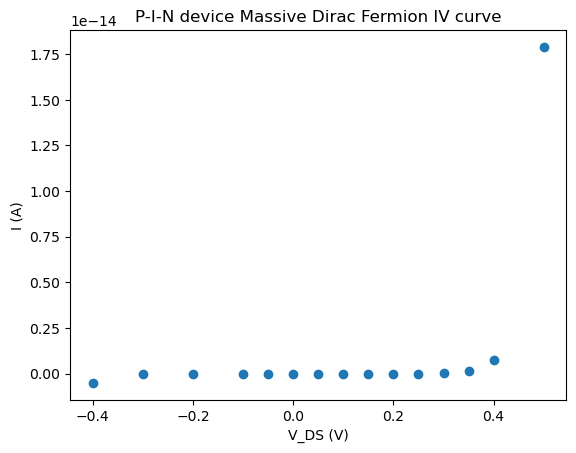

In [13]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("iv_dirac.npz")
plt.scatter(d["V_DS"], d["I"])
plt.xlabel("V_DS (V)")
plt.ylabel("I (A)")
plt.title("P-I-N device Massive Dirac Fermion IV curve")
plt.show()

In [ ]:
"""Three-bias snapshots: V_DS = -0.5, 0, +0.5 — visualize device state.

For each bias:
  - 2D mesh (Delaunay triangulation)
  - 2D charge density rho(x, y)
  - 2D electrostatic potential phi(x, y)
  - 1D slice averages of n, p, rho, phi
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from scipy.spatial import Delaunay


def _grid_from_pos(pos, vals):
    """Reshape per-atom array onto 2D (W, L) grid by sorting positions."""
    x_unique = np.unique(pos[:, 0])
    y_unique = np.unique(pos[:, 1])
    L = len(x_unique); W = len(y_unique)
    grid = np.full((W, L), np.nan)
    for (xi, yi), v in zip(pos, vals):
        col = np.searchsorted(x_unique, xi)
        row = np.searchsorted(y_unique, yi)
        grid[row, col] = v
    return grid, x_unique, y_unique


def plot_snapshot(res, V_DS, save_path):
    """Big figure: 2D mesh, 2D rho, 2D phi, 1D profiles."""
    pos = res["pos"]
    L = res["L_slices"]
    sl_idx = res["slice_idx"]
    a = res["a_lat"]
    x_axis = np.arange(L) * a

    rho_grid, x_arr, y_arr = _grid_from_pos(pos, res["rho"])
    phi_grid, _, _         = _grid_from_pos(pos, res["phi_site"] * V0)
    extent = [x_arr.min(), x_arr.max(), y_arr.min(), y_arr.max()]

    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.2, 1.2, 1.0])

    # Row 1: mesh + 2D rho + 2D phi
    ax = fig.add_subplot(gs[0, 0])
    tri = Delaunay(pos)
    triang = Triangulation(pos[:, 0], pos[:, 1], triangles=tri.simplices)
    ax.triplot(triang, "k-", lw=0.2, alpha=0.6)
    ax.scatter(pos[:, 0], pos[:, 1], s=1, c="red")
    ax.set_aspect("equal")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    ax.set_title(f"FE mesh ({len(pos)} nodes, {len(tri.simplices)} tri)")

    ax = fig.add_subplot(gs[0, 1])
    rho_max = np.nanmax(np.abs(rho_grid))
    im = ax.imshow(rho_grid, origin="lower", aspect="auto",
                    extent=extent, cmap="RdBu_r",
                    vmin=-rho_max, vmax=rho_max)
    ax.set_title(r"net charge $\rho(x, y)$")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    plt.colorbar(im, ax=ax)

    ax = fig.add_subplot(gs[0, 2])
    im = ax.imshow(phi_grid, origin="lower", aspect="auto",
                    extent=extent, cmap="viridis")
    ax.set_title(r"$\phi(x, y)$ (V)")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    plt.colorbar(im, ax=ax)

    # Row 2: 2D n and 2D p
    n_grid, _, _ = _grid_from_pos(pos, res["n"])
    p_grid, _, _ = _grid_from_pos(pos, res["p"])

    ax = fig.add_subplot(gs[1, 0])
    im = ax.imshow(n_grid, origin="lower", aspect="auto",
                    extent=extent, cmap="Blues")
    ax.set_title("electron density n(x, y)")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    plt.colorbar(im, ax=ax)

    ax = fig.add_subplot(gs[1, 1])
    im = ax.imshow(p_grid, origin="lower", aspect="auto",
                    extent=extent, cmap="Reds")
    ax.set_title("hole density p(x, y)")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    plt.colorbar(im, ax=ax)

    ax = fig.add_subplot(gs[1, 2])
    tcf = ax.tricontourf(triang, res["phi_site"] * V0, levels=30, cmap="viridis")
    ax.triplot(triang, "k-", lw=0.1, alpha=0.25)
    ax.set_aspect("equal")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    ax.set_title(r"FE mesh + $\phi$ contours")
    plt.colorbar(tcf, ax=ax)

    # Row 3: 1D slice averages
    def per_slice(arr): return to_slice(arr, sl_idx, L)

    ax = fig.add_subplot(gs[2, 0])
    ax.plot(x_axis, per_slice(res["n"]), "C0-", lw=1.5, label="n")
    ax.plot(x_axis, per_slice(res["p"]), "C3-", lw=1.5, label="p")
    ax.plot(x_axis, per_slice(res["Nd"]), "C0--", alpha=0.5, label="Nd")
    ax.plot(x_axis, per_slice(res["Na"]), "C3--", alpha=0.5, label="Na")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("density per site")
    ax.set_title("Carrier and doping profiles (slice avg)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[2, 1])
    ax.plot(x_axis, per_slice(res["rho"]), "k-", lw=1.5)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("x (nm)"); ax.set_ylabel(r"$\rho$")
    ax.set_title("Net charge (slice avg)")
    ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[2, 2])
    ax.plot(x_axis, per_slice(res["phi_site"]) * V0, "C2-", lw=1.5)
    ax.set_xlabel("x (nm)"); ax.set_ylabel(r"$\phi$ (V)")
    ax.set_title(r"$\phi(x)$ (slice avg)")
    ax.grid(alpha=0.3)

    fig.suptitle(f"Dirac diode at V_DS = {V_DS:+.2f} V", fontsize=14, y=1.00)
    plt.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved {save_path}")


if __name__ == "__main__":
    a_lat = 0.5
    t_hop = 1.0
    m_mass = 0.3
    eps_r = 11.7
    W_rows = 20
    L_slices = 200
    L_p, L_i = 60, 80

    Nd_value = doping_per_site(1e20, a_lat)
    Na_value = doping_per_site(1e20, a_lat)
    print(f"Nd={Nd_value:.4f}, Na={Na_value:.4f}, m={m_mass}")

    E_grid = np.linspace(-3.0, 3.0, 121)

    # Auto-tune once
    print("\nAuto-tuning lead BCs...")
    phi_p_BC, phi_n_BC = find_neutral_phi_dirac(
        W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
        Nd_value=Nd_value, Na_value=Na_value,
        t_hop=t_hop, a_lat=a_lat, m=m_mass,
        mu_ref=0.0, eta_negf=0.030,
        phi_range=(-1.0, 1.0), n_points=21,
        E_grid=E_grid, verbose=True,
    )
    print(f"\nphi_p_BC = {phi_p_BC:+.4f}, phi_n_BC = {phi_n_BC:+.4f}")
    print(f"V_bi = {phi_n_BC - phi_p_BC:+.4f} V")

    # Loop over the three bias points
    for V_DS in [-0.5, 0.0, 0.5]:
        print(f"\n{'='*60}")
        print(f"Solving V_DS = {V_DS:+.2f} V")
        print(f"{'='*60}")
        res = self_consistent_solve_dirac(
            W_rows=W_rows, L_slices=L_slices, L_p=L_p, L_i=L_i,
            Nd_value=Nd_value, Na_value=Na_value,
            t_hop=t_hop, a_lat=a_lat, m=m_mass,
            V_DS=V_DS, mu_ref=0.0,
            phi_p_BC=phi_p_BC, phi_n_BC=phi_n_BC,
            eps_r=eps_r, eta_negf=0.030, E_grid=E_grid,
            mix=0.5, max_iter=40, tol=1e-3,
            verbose=True,
        )
        plot_snapshot(res, V_DS, save_path=f"snapshot_V{V_DS:+.2f}.png")

    print("\nDone.")

Nd=0.0125, Na=0.0125, m=0.3

Auto-tuning lead BCs...
  auto-tune Dirac (m=0.3, gap=0.6) phi sweep (21 pts)...
    phi=-1.000  rho_p=-0.5463  rho_n=-0.5213
    phi=-0.900  rho_p=-0.5120  rho_n=-0.4870
    phi=-0.800  rho_p=-0.4673  rho_n=-0.4423
    phi=-0.700  rho_p=-0.4071  rho_n=-0.3821
    phi=-0.600  rho_p=-0.3485  rho_n=-0.3235
    phi=-0.500  rho_p=-0.2951  rho_n=-0.2701
    phi=-0.400  rho_p=-0.2417  rho_n=-0.2167
    phi=-0.300  rho_p=-0.1867  rho_n=-0.1617
    phi=-0.200  rho_p=-0.1293  rho_n=-0.1043
    phi=-0.100  rho_p=-0.0700  rho_n=-0.0450
    phi=+0.000  rho_p=-0.0125  rho_n=+0.0125
    phi=+0.100  rho_p=+0.0450  rho_n=+0.0700
    phi=+0.200  rho_p=+0.1043  rho_n=+0.1293
    phi=+0.300  rho_p=+0.1617  rho_n=+0.1867
    phi=+0.400  rho_p=+0.2167  rho_n=+0.2417
    phi=+0.500  rho_p=+0.2701  rho_n=+0.2951
    phi=+0.600  rho_p=+0.3235  rho_n=+0.3485
    phi=+0.700  rho_p=+0.3821  rho_n=+0.4071
    phi=+0.800  rho_p=+0.4423  rho_n=+0.4673
    phi=+0.900  rho_p=+0.4870  rho_